# EDA Historiques

## SECTION 1 : Setup & Compréhension initiale

### Imports et configuration

In [3]:
import pandas as pd
import sys
from pathlib import Path
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

project_root = Path.cwd().parent  # notebook/ → P12_systeme_reco_agriculture/
sys.path.insert(0, str(project_root))  # Dit à Python : "Cherche aussi ici !"

from config.paths import DONNEES_HISTORIQUES, DONNEES_AGRO_CLIMATIQUES
from config.config import RANDOM_STATE

### Chargement et Vue d'ensemble

In [4]:
df_historiques = pd.read_csv(DONNEES_HISTORIQUES / "crop_yield.csv")

In [5]:
df_historiques.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


### Informations générales

In [6]:
df_historiques.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Region                  1000000 non-null  object 
 1   Soil_Type               1000000 non-null  object 
 2   Crop                    1000000 non-null  object 
 3   Rainfall_mm             1000000 non-null  float64
 4   Temperature_Celsius     1000000 non-null  float64
 5   Fertilizer_Used         1000000 non-null  bool   
 6   Irrigation_Used         1000000 non-null  bool   
 7   Weather_Condition       1000000 non-null  object 
 8   Days_to_Harvest         1000000 non-null  int64  
 9   Yield_tons_per_hectare  1000000 non-null  float64
dtypes: bool(2), float64(3), int64(1), object(4)
memory usage: 62.9+ MB


In [7]:
df_historiques.shape

(1000000, 10)

In [8]:
df_historiques.describe()

,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,549.981901,27.504965,104.495025,4.649472
std,259.851320,7.220608,25.953412,1.696572
min,100.000896,15.000034,60.000000,-1.147613
25%,324.891090,21.254502,82.000000,3.417637
50%,550.124061,27.507365,104.000000,4.651808
75%,774.738520,33.753267,127.000000,5.879200
max,999.998098,39.999997,149.000000,9.963372


### Valeurs manquantes 

In [ ]:
df_historiques.isnull().sum()

In [ ]:
msno.matrix(df_historiques)

### Grille combinatoire

In [11]:
# Grille combinatoire sans les booléens

# Combinaisons avec Region
n_combinations_with_region = df_historiques.groupby([
    'Region', 'Crop', 'Soil_Type', 'Weather_Condition'
]).size()

print("=== AVEC REGION ===")
print(f"Combinaisons observées : {len(n_combinations_with_region)}")

# Combinaisons théoriques max
n_regions = df_historiques['Region'].nunique()
n_crops = df_historiques['Crop'].nunique()
n_soils = df_historiques['Soil_Type'].nunique()
n_weather = df_historiques['Weather_Condition'].nunique()

max_combinations = n_regions * n_crops * n_soils * n_weather
print(f"Combinaisons théoriques : {max_combinations}")
print(f"Couverture : {len(n_combinations_with_region)/max_combinations*100:.1f}%")

# Distribution des counts
print("\nDistribution counts par combinaison :")
print(n_combinations_with_region.value_counts().head(10))
print(f"Écart-type : {n_combinations_with_region.std():.2f}")

=== AVEC REGION ===
Combinaisons observées : 432
Combinaisons théoriques : 432
Couverture : 100.0%

Distribution counts par combinaison :
2331    8
2321    8
2294    7
2311    7
2291    7
2346    6
2317    6
2296    6
2310    6
2303    6
Name: count, dtype: int64
Écart-type : 47.23


In [10]:
# Grille combinatoire COMPLÈTE (avec booléens)
n_combinations_complete = df_historiques.groupby([
    'Region', 'Crop', 'Soil_Type', 'Weather_Condition',
    'Fertilizer_Used', 'Irrigation_Used'
]).size()

print("\n=== GRILLE COMPLÈTE (avec Fertilizer + Irrigation) ===")
print(f"Combinaisons observées : {len(n_combinations_complete)}")
print(f"Combinaisons théoriques : {432 * 4} (432 × 4 contextes)")
print(f"Couverture : {len(n_combinations_complete)/(432*4)*100:.1f}%")
print(f"\nMoyenne obs/combo : {n_combinations_complete.mean():.0f}")
print(f"Min/Max : {n_combinations_complete.min()} / {n_combinations_complete.max()}")


=== GRILLE COMPLÈTE (avec Fertilizer + Irrigation) ===
Combinaisons observées : 1728
Combinaisons théoriques : 1728 (432 × 4 contextes)
Couverture : 100.0%

Moyenne obs/combo : 579
Min/Max : 500 / 661


**Conclusion :**
On observe une grille combinatoire exhaustive (1728 combinaisons)

## SECTION 2 : Analyse des variables individuelles

In [9]:
# TEST 1 : Corrélation Rainfall × Temperature
print("=== CORRÉLATION RAINFALL × TEMPERATURE ===")
corr_rain_temp = df_historiques[['Rainfall_mm', 'Temperature_Celsius']].corr()
print(corr_rain_temp)
print(f"\nCoefficient : {corr_rain_temp.iloc[0,1]:.4f}")

# TEST 2 : Temperature moyenne PAR Weather_Condition
print("\n=== TEMPÉRATURE PAR WEATHER_CONDITION ===")
temp_by_weather = df_historiques.groupby('Weather_Condition')['Temperature_Celsius'].agg(['mean', 'std'])
print(temp_by_weather)

# TEST 3 : Rainfall ET Temperature PAR Weather_Condition
print("\n=== RAINFALL ET TEMPERATURE PAR WEATHER_CONDITION ===")
weather_profile = df_historiques.groupby('Weather_Condition')[['Rainfall_mm', 'Temperature_Celsius']].mean()
print(weather_profile)

# TEST 4 : Peut-on prédire Weather avec combinaison linéaire ?
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Encoder Weather
le_weather = LabelEncoder()
y_weather = le_weather.fit_transform(df_historiques['Weather_Condition'])

# Prédire Weather avec Rainfall + Temperature
X_climate = df_historiques[['Rainfall_mm', 'Temperature_Celsius']]

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train_w, y_test_w = train_test_split(X_climate, y_weather, test_size=0.2, random_state=42)

# Modèle
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train_w)
y_pred_w = lr.predict(X_test)

accuracy = accuracy_score(y_test_w, y_pred_w)

print("\n=== PRÉDICTION WEATHER VIA RAINFALL + TEMPERATURE ===")
print(f"Accuracy : {accuracy:.2%}")
print(f"\nSi accuracy ≈ 33% (aléatoire) → Weather indépendant")
print(f"Si accuracy > 50% → Weather prédictible par climat")

# Coefficients
print(f"\nCoefficients modèle :")
print(f"Rainfall    : {lr.coef_[0][0]:.6f}")
print(f"Temperature : {lr.coef_[0][1]:.6f}")

=== CORRÉLATION RAINFALL × TEMPERATURE ===
                     Rainfall_mm  Temperature_Celsius
Rainfall_mm             1.000000            -0.000123
Temperature_Celsius    -0.000123             1.000000

Coefficient : -0.0001

=== TEMPÉRATURE PAR WEATHER_CONDITION ===
                        mean       std
Weather_Condition                     
Cloudy             27.517724  7.219018
Rainy              27.494234  7.225456
Sunny              27.502974  7.217347

=== RAINFALL ET TEMPERATURE PAR WEATHER_CONDITION ===
                   Rainfall_mm  Temperature_Celsius
Weather_Condition                                  
Cloudy              549.474540            27.517724
Rainy               550.128880            27.494234
Sunny               550.340649            27.502974

=== PRÉDICTION WEATHER VIA RAINFALL + TEMPERATURE ===
Accuracy : 33.49%

Si accuracy ≈ 33% (aléatoire) → Weather indépendant
Si accuracy > 50% → Weather prédictible par climat

Coefficients modèle :
Rainfall    : -0.00

In [15]:
# Corrélation avec variables continues
print("Corrélations Days_to_Harvest :")
print(df_historiques[['Days_to_Harvest', 'Rainfall_mm', 'Temperature_Celsius', 
                      'Yield_tons_per_hectare']].corr()['Days_to_Harvest'])

# Impact Fertilizer/Irrigation
print("\n=== Impact Fertilizer ===")
print(df_historiques.groupby('Fertilizer_Used')['Days_to_Harvest'].mean())

print("\n=== Impact Irrigation ===")
print(df_historiques.groupby('Irrigation_Used')['Days_to_Harvest'].mean())

# Par culture (durées naturelles différentes)
print("\n=== Par Crop ===")
print(df_historiques.groupby('Crop')['Days_to_Harvest'].mean().sort_values())

Corrélations Days_to_Harvest :
Days_to_Harvest           1.000000
Rainfall_mm              -0.002669
Temperature_Celsius      -0.000731
Yield_tons_per_hectare   -0.002591
Name: Days_to_Harvest, dtype: float64

=== Impact Fertilizer ===
Fertilizer_Used
False    104.521723
True     104.468320
Name: Days_to_Harvest, dtype: float64

=== Impact Irrigation ===
Irrigation_Used
False    104.527025
True     104.462959
Name: Days_to_Harvest, dtype: float64

=== Par Crop ===
Crop
Barley     104.425646
Soybean    104.455945
Rice       104.500875
Wheat      104.514900
Cotton     104.533800
Maize      104.538927
Name: Days_to_Harvest, dtype: float64


In [16]:
# Rendements par combinaison complète
combo_yields = df_historiques.groupby([
    'Region', 'Crop', 'Soil_Type', 'Weather_Condition',
    'Fertilizer_Used', 'Irrigation_Used'
])['Yield_tons_per_hectare'].agg(['mean', 'std', 'count'])

print("=== RENDEMENTS PAR COMBINAISON COMPLÈTE ===")
print(f"Nombre de combinaisons uniques : {len(combo_yields)}")
print("\nTop 10 rendements :")
print(combo_yields.sort_values('mean', ascending=False).head(10))
print("\nBottom 10 rendements :")
print(combo_yields.sort_values('mean').head(10))

# Variance ENTRE combinaisons
print(f"\nVariance ENTRE combinaisons : {combo_yields['mean'].var():.4f}")
print(f"Écart-type : {combo_yields['mean'].std():.4f}")

=== RENDEMENTS PAR COMBINAISON COMPLÈTE ===
Nombre de combinaisons uniques : 1728

Top 10 rendements :
                                                                                mean  \
Region Crop    Soil_Type Weather_Condition Fertilizer_Used Irrigation_Used             
East   Cotton  Peaty     Cloudy            True            True             6.186906   
West   Rice    Sandy     Rainy             True            True             6.181474   
               Peaty     Sunny             True            True             6.166290   
South  Soybean Peaty     Rainy             True            True             6.159128   
West   Soybean Sandy     Rainy             True            True             6.152356   
               Loam      Rainy             True            True             6.129400   
South  Cotton  Peaty     Rainy             True            True             6.124940   
North  Barley  Chalky    Sunny             True            True             6.118065   
               Cl

In [17]:
# Fixer Fertilizer=True, Irrigation=True
# Voir si Crop/Soil/Weather ont encore un impact
best_context = df_historiques[
    (df_historiques['Fertilizer_Used'] == True) & 
    (df_historiques['Irrigation_Used'] == True)
]

print("=== DANS CONTEXTE OPTIMAL (Fert=True, Irrig=True) ===")
print(best_context.groupby(['Crop', 'Soil_Type', 'Weather_Condition'])['Yield_tons_per_hectare'].mean().sort_values(ascending=False).head(10))

=== DANS CONTEXTE OPTIMAL (Fert=True, Irrig=True) ===
Crop     Soil_Type  Weather_Condition
Barley   Chalky     Sunny                6.067200
Soybean  Peaty      Rainy                6.066625
         Silt       Cloudy               6.064136
Barley   Clay       Rainy                6.051481
Soybean  Chalky     Cloudy               6.049145
Wheat    Loam       Rainy                6.046653
Rice     Loam       Rainy                6.046571
Soybean  Silt       Rainy                6.042370
Rice     Sandy      Rainy                6.037542
Soybean  Silt       Sunny                6.036796
Name: Yield_tons_per_hectare, dtype: float64


In [18]:
# Test : Days_to_Harvest prédit par combinaisons ?

# 1. Variance entre combinaisons complètes
combo_days = df_historiques.groupby([
    'Region', 'Crop', 'Soil_Type', 'Weather_Condition',
    'Fertilizer_Used', 'Irrigation_Used'
])['Days_to_Harvest'].agg(['mean', 'std', 'count'])

print("=== DAYS_TO_HARVEST PAR COMBINAISON ===")
print(f"Nombre de combinaisons : {len(combo_days)}")
print("\nTop 10 (cycles les plus longs) :")
print(combo_days.sort_values('mean', ascending=False).head(10))
print("\nBottom 10 (cycles les plus courts) :")
print(combo_days.sort_values('mean').head(10))

print(f"\nVariance ENTRE combinaisons : {combo_days['mean'].var():.4f}")
print(f"Écart-type : {combo_days['mean'].std():.4f}")

# 2. Test dans contexte optimal (Fert=True, Irrig=True)
best_context = df_historiques[
    (df_historiques['Fertilizer_Used'] == True) & 
    (df_historiques['Irrigation_Used'] == True)
]

print("\n=== DANS CONTEXTE OPTIMAL ===")
days_optimal = best_context.groupby(['Region', 'Crop', 'Soil_Type', 'Weather_Condition'])['Days_to_Harvest'].mean()
print("\nTop 10 cycles les plus longs :")
print(days_optimal.sort_values(ascending=False).head(10))
print("\nTop 10 cycles les plus courts :")
print(days_optimal.sort_values().head(10))
print(f"\nÉcart max-min : {days_optimal.max() - days_optimal.min():.2f} jours")

=== DAYS_TO_HARVEST PAR COMBINAISON ===
Nombre de combinaisons : 1728

Top 10 (cycles les plus longs) :
                                                                                 mean  \
Region Crop   Soil_Type Weather_Condition Fertilizer_Used Irrigation_Used               
North  Cotton Silt      Sunny             False           False            107.995008   
South  Barley Peaty     Sunny             True            False            107.963028   
East   Wheat  Clay      Sunny             False           False            107.830000   
South  Cotton Silt      Cloudy            False           True             107.805893   
West   Wheat  Clay      Sunny             True            True             107.516340   
South  Maize  Sandy     Sunny             True            False            107.508021   
East   Barley Silt      Cloudy            True            False            107.507168   
North  Rice   Sandy     Rainy             False           True             107.458054   
      

In [19]:
# Distribution lignes par combinaison
combo_counts = df_historiques.groupby([
    'Region', 'Crop', 'Soil_Type', 'Weather_Condition',
    'Fertilizer_Used', 'Irrigation_Used'
]).size()

print("=== GRANULARITÉ ===")
print(f"Min observations/combo : {combo_counts.min()}")
print(f"Max observations/combo : {combo_counts.max()}")
print(f"Moyenne : {combo_counts.mean():.0f}")
print(f"Médiane : {combo_counts.median():.0f}")
print(f"\nDistribution :")
print(combo_counts.value_counts().head(20))

# Si tous ≈ 578-580 → Échantillonnage équilibré
# Si variance élevée → Échantillonnage aléatoire


=== GRANULARITÉ ===
Min observations/combo : 500
Max observations/combo : 661
Moyenne : 579
Médiane : 579

Distribution :
586    39
596    34
580    34
574    34
582    34
577    33
575    31
581    31
585    31
576    31
594    30
583    30
592    29
561    27
584    27
567    26
563    26
573    25
564    25
603    25
Name: count, dtype: int64


In [21]:
# 1. Temperature moyenne par Region
print("=== TEMPÉRATURE PAR RÉGION ===")
print(df_historiques.groupby('Region')['Temperature_Celsius'].agg(['mean', 'std']))

# 2. Rainfall par Region (exposition peut affecter pluie)
print("\n=== RAINFALL PAR RÉGION ===")
print(df_historiques.groupby('Region')['Rainfall_mm'].agg(['mean', 'std']))

# 3. Yield par Region (déjà testé mais refaisons)
print("\n=== YIELD PAR RÉGION ===")
print(df_historiques.groupby('Region')['Yield_tons_per_hectare'].agg(['mean', 'std']))

# 4. Days_to_Harvest par Region (exposition → cycle?)
print("\n=== DAYS_TO_HARVEST PAR RÉGION ===")
print(df_historiques.groupby('Region')['Days_to_Harvest'].agg(['mean', 'std']))

# 5. CRITIQUE : Corrélation Region × Temperature
# Si Region = exposition → North devrait être plus froid
print("\n=== TEST COHÉRENCE EXPOSITION ===")
region_temp = df_historiques.groupby('Region')['Temperature_Celsius'].mean().sort_values()
print(region_temp)
print("\nAttendus si exposition:")
print("North → Temperature la plus basse")
print("South → Temperature la plus haute")

=== TEMPÉRATURE PAR RÉGION ===
             mean       std
Region                     
East    27.503226  7.218823
North   27.496045  7.219249
South   27.502708  7.216663
West    27.517882  7.227714

=== RAINFALL PAR RÉGION ===
              mean         std
Region                        
East    549.243755  259.935570
North   550.793416  260.020785
South   550.013776  259.938458
West    549.875231  259.509446

=== YIELD PAR RÉGION ===
            mean       std
Region                    
East    4.645594  1.697160
North   4.654114  1.696369
South   4.648843  1.697191
West    4.649331  1.695569

=== DAYS_TO_HARVEST PAR RÉGION ===
              mean        std
Region                       
East    104.535545  25.942882
North   104.502588  25.972629
South   104.494169  25.944515
West    104.447855  25.953669

=== TEST COHÉRENCE EXPOSITION ===
Region
North    27.496045
South    27.502708
East     27.503226
West     27.517882
Name: Temperature_Celsius, dtype: float64

Attendus si expositio

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

# ÉCHANTILLON 100k lignes
df_test = df_historiques.sample(100000, random_state=42).copy()

print(f"Taille échantillon : {len(df_test):,} lignes")

# Encoder catégories
le_crop = LabelEncoder()
le_soil = LabelEncoder()
le_weather = LabelEncoder()
le_region = LabelEncoder()

df_test['Crop_encoded'] = le_crop.fit_transform(df_test['Crop'])
df_test['Soil_encoded'] = le_soil.fit_transform(df_test['Soil_Type'])
df_test['Weather_encoded'] = le_weather.fit_transform(df_test['Weather_Condition'])
df_test['Region_encoded'] = le_region.fit_transform(df_test['Region'])

# Convertir booléens en int
df_test['Fertilizer_int'] = df_test['Fertilizer_Used'].astype(int)
df_test['Irrigation_int'] = df_test['Irrigation_Used'].astype(int)

# MODÈLE SIMPLE (3 variables essentielles)
X_simple = df_test[['Rainfall_mm', 'Fertilizer_int', 'Irrigation_int']]

# MODÈLE COMPLEXE (+ combinaisons catégorielles)
X_complex = df_test[['Rainfall_mm', 'Fertilizer_int', 'Irrigation_int',
                      'Crop_encoded', 'Soil_encoded', 'Weather_encoded', 'Region_encoded']]

y = df_test['Yield_tons_per_hectare']

# Split
X_simple_train, X_simple_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)
X_complex_train, X_complex_test, _, _ = train_test_split(
    X_complex, y, test_size=0.2, random_state=42
)

# MODÈLE SIMPLE
print("\n=== MODÈLE SIMPLE (Rainfall + Fertilizer + Irrigation) ===")
rf_simple = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_simple.fit(X_simple_train, y_train)
y_pred_simple = rf_simple.predict(X_simple_test)

r2_simple = r2_score(y_test, y_pred_simple)
mae_simple = mean_absolute_error(y_test, y_pred_simple)
print(f"R² : {r2_simple:.4f}")
print(f"MAE : {mae_simple:.4f} t/ha")

# MODÈLE COMPLEXE
print("\n=== MODÈLE COMPLEXE (+ Crop + Soil + Weather + Region) ===")
rf_complex = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_complex.fit(X_complex_train, y_train)
y_pred_complex = rf_complex.predict(X_complex_test)

r2_complex = r2_score(y_test, y_pred_complex)
mae_complex = mean_absolute_error(y_test, y_pred_complex)
print(f"R² : {r2_complex:.4f}")
print(f"MAE : {mae_complex:.4f} t/ha")

# Feature importance
import pandas as pd
importance_complex = pd.DataFrame({
    'Feature': ['Rainfall_mm', 'Fertilizer', 'Irrigation', 'Crop', 'Soil', 'Weather', 'Region'],
    'Importance': rf_complex.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nFeature Importance:")
print(importance_complex)

# COMPARAISON
print("\n" + "="*60)
print("=== COMPARAISON FINALE ===")
print(f"R² Simple   : {r2_simple:.4f}")
print(f"R² Complexe : {r2_complex:.4f}  (Δ = +{(r2_complex - r2_simple):.4f})")

print(f"\nMAE Simple   : {mae_simple:.4f} t/ha")
print(f"MAE Complexe : {mae_complex:.4f} t/ha  (Δ = {(mae_complex - mae_simple):.4f})")

# VERDICT
delta_r2 = r2_complex - r2_simple
print("\n" + "="*60)
print("=== VERDICT ===")
if delta_r2 < 0.02:
    print("❌ Combinaisons catégorielles apportent PEU de valeur (<2% R²)")
    print("✅ RECOMMANDATION : Utiliser UNIQUEMENT Rainfall + Fertilizer + Irrigation")
    print("   → Proxys FAO : 2 variables booléennes seulement")
elif delta_r2 < 0.05:
    print("⚠️ Combinaisons apportent valeur MODÉRÉE (2-5% R²)")
    print("⚠️ RECOMMANDATION : À évaluer selon complexité projet")
else:
    print("✅ Combinaisons apportent valeur SIGNIFICATIVE (>5% R²)")
    print("✅ RECOMMANDATION : Conserver les combinaisons catégorielles")
    print("   → Proxys FAO : Créer proxys géographiques Crop/Soil/Weather")

Taille échantillon : 100,000 lignes

=== MODÈLE SIMPLE (Rainfall + Fertilizer + Irrigation) ===
R² : 0.8625
MAE : 0.5037 t/ha

=== MODÈLE COMPLEXE (+ Crop + Soil + Weather + Region) ===
R² : 0.8937
MAE : 0.4427 t/ha

Feature Importance:
       Feature  Importance
0  Rainfall_mm    0.639274
1   Fertilizer    0.195772
2   Irrigation    0.122981
3         Crop    0.012643
4         Soil    0.012464
6       Region    0.009477
5      Weather    0.007389

=== COMPARAISON FINALE ===
R² Simple   : 0.8625
R² Complexe : 0.8937  (Δ = +0.0312)

MAE Simple   : 0.5037 t/ha
MAE Complexe : 0.4427 t/ha  (Δ = -0.0610)

=== VERDICT ===
⚠️ Combinaisons apportent valeur MODÉRÉE (2-5% R²)
⚠️ RECOMMANDATION : À évaluer selon complexité projet


In [23]:
# MODÈLE ULTRA (+ Temperature + Days_to_Harvest)
X_ultra = df_test[['Rainfall_mm', 'Fertilizer_int', 'Irrigation_int',
                    'Crop_encoded', 'Soil_encoded', 'Weather_encoded', 'Region_encoded',
                    'Temperature_Celsius', 'Days_to_Harvest']]

X_ultra_train, X_ultra_test, _, _ = train_test_split(
    X_ultra, y, test_size=0.2, random_state=42
)

print("\n=== MODÈLE ULTRA (+ Temperature + Days_to_Harvest) ===")
rf_ultra = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_ultra.fit(X_ultra_train, y_train)
y_pred_ultra = rf_ultra.predict(X_ultra_test)

r2_ultra = r2_score(y_test, y_pred_ultra)
mae_ultra = mean_absolute_error(y_test, y_pred_ultra)
print(f"R² : {r2_ultra:.4f}")
print(f"MAE : {mae_ultra:.4f} t/ha")

# Feature importance
importance_ultra = pd.DataFrame({
    'Feature': ['Rainfall_mm', 'Fertilizer', 'Irrigation', 'Crop', 'Soil', 'Weather', 
                'Region', 'Temperature', 'Days_to_Harvest'],
    'Importance': rf_ultra.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nFeature Importance:")
print(importance_ultra)

# COMPARAISON FINALE COMPLÈTE
print("\n" + "="*70)
print("=== COMPARAISON FINALE COMPLÈTE ===")
print(f"R² Simple   : {r2_simple:.4f}")
print(f"R² Complexe : {r2_complex:.4f}  (Δ = +{(r2_complex - r2_simple):.4f})")
print(f"R² Ultra    : {r2_ultra:.4f}  (Δ = +{(r2_ultra - r2_simple):.4f})")

print(f"\nMAE Simple   : {mae_simple:.4f} t/ha")
print(f"MAE Complexe : {mae_complex:.4f} t/ha")
print(f"MAE Ultra    : {mae_ultra:.4f} t/ha")

print("\n" + "="*70)
print("=== VERDICT FINAL ===")
delta_ultra = r2_ultra - r2_complex
if delta_ultra < 0.01:
    print("❌ Temperature + Days_to_Harvest n'apportent RIEN (<1%)")
    print("✅ MODÈLE RECOMMANDÉ : Complexe (7 features)")
else:
    print(f"✅ Temperature + Days apportent {delta_ultra:.2%} supplémentaires")
    print("✅ MODÈLE RECOMMANDÉ : Ultra (9 features)")


=== MODÈLE ULTRA (+ Temperature + Days_to_Harvest) ===
R² : 0.9060
MAE : 0.4170 t/ha

Feature Importance:
           Feature  Importance
0      Rainfall_mm    0.609842
1       Fertilizer    0.195772
2       Irrigation    0.122981
7      Temperature    0.029512
8  Days_to_Harvest    0.017737
3             Crop    0.007323
4             Soil    0.007284
6           Region    0.005414
5          Weather    0.004136

=== COMPARAISON FINALE COMPLÈTE ===
R² Simple   : 0.8625
R² Complexe : 0.8937  (Δ = +0.0312)
R² Ultra    : 0.9060  (Δ = +0.0435)

MAE Simple   : 0.5037 t/ha
MAE Complexe : 0.4427 t/ha
MAE Ultra    : 0.4170 t/ha

=== VERDICT FINAL ===
✅ Temperature + Days apportent 1.24% supplémentaires
✅ MODÈLE RECOMMANDÉ : Ultra (9 features)


In [23]:
# MODÈLE ULTRA-MINI (+ Days_to_Harvest)
X_ultra = df_test[['Rainfall_mm', 'Fertilizer_int', 'Irrigation_int',
                    'Crop_encoded', 'Soil_encoded', 'Weather_encoded', 'Region_encoded',
                    'Temperature_Celsius', 'Days_to_Harvest']]

X_ultra_train, X_ultra_test, _, _ = train_test_split(
    X_ultra, y, test_size=0.2, random_state=42
)

print("\n=== MODÈLE ULTRA (+ Temperature + Days_to_Harvest) ===")
rf_ultra = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_ultra.fit(X_ultra_train, y_train)
y_pred_ultra = rf_ultra.predict(X_ultra_test)

r2_ultra = r2_score(y_test, y_pred_ultra)
mae_ultra = mean_absolute_error(y_test, y_pred_ultra)
print(f"R² : {r2_ultra:.4f}")
print(f"MAE : {mae_ultra:.4f} t/ha")

# Feature importance
importance_ultra = pd.DataFrame({
    'Feature': ['Rainfall_mm', 'Fertilizer', 'Irrigation', 'Crop', 'Soil', 'Weather', 
                'Region', 'Temperature', 'Days_to_Harvest'],
    'Importance': rf_ultra.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nFeature Importance:")
print(importance_ultra)

# COMPARAISON FINALE COMPLÈTE
print("\n" + "="*70)
print("=== COMPARAISON FINALE COMPLÈTE ===")
print(f"R² Simple   : {r2_simple:.4f}")
print(f"R² Complexe : {r2_complex:.4f}  (Δ = +{(r2_complex - r2_simple):.4f})")
print(f"R² Ultra    : {r2_ultra:.4f}  (Δ = +{(r2_ultra - r2_simple):.4f})")

print(f"\nMAE Simple   : {mae_simple:.4f} t/ha")
print(f"MAE Complexe : {mae_complex:.4f} t/ha")
print(f"MAE Ultra    : {mae_ultra:.4f} t/ha")

print("\n" + "="*70)
print("=== VERDICT FINAL ===")
delta_ultra = r2_ultra - r2_complex
if delta_ultra < 0.01:
    print("❌ Temperature + Days_to_Harvest n'apportent RIEN (<1%)")
    print("✅ MODÈLE RECOMMANDÉ : Complexe (7 features)")
else:
    print(f"✅ Temperature + Days apportent {delta_ultra:.2%} supplémentaires")
    print("✅ MODÈLE RECOMMANDÉ : Ultra (9 features)")


=== MODÈLE ULTRA (+ Temperature + Days_to_Harvest) ===
R² : 0.9060
MAE : 0.4170 t/ha

Feature Importance:
           Feature  Importance
0      Rainfall_mm    0.609842
1       Fertilizer    0.195772
2       Irrigation    0.122981
7      Temperature    0.029512
8  Days_to_Harvest    0.017737
3             Crop    0.007323
4             Soil    0.007284
6           Region    0.005414
5          Weather    0.004136

=== COMPARAISON FINALE COMPLÈTE ===
R² Simple   : 0.8625
R² Complexe : 0.8937  (Δ = +0.0312)
R² Ultra    : 0.9060  (Δ = +0.0435)

MAE Simple   : 0.5037 t/ha
MAE Complexe : 0.4427 t/ha
MAE Ultra    : 0.4170 t/ha

=== VERDICT FINAL ===
✅ Temperature + Days apportent 1.24% supplémentaires
✅ MODÈLE RECOMMANDÉ : Ultra (9 features)


In [24]:
# MODÈLE INTERMÉDIAIRE (Complexe + Days_to_Harvest, SANS Temperature)
X_intermediate = df_test[['Rainfall_mm', 'Fertilizer_int', 'Irrigation_int',
                           'Crop_encoded', 'Soil_encoded', 'Weather_encoded', 'Region_encoded',
                           'Days_to_Harvest']]

X_inter_train, X_inter_test, _, _ = train_test_split(
    X_intermediate, y, test_size=0.2, random_state=42
)

print("\n" + "="*70)
print("=== MODÈLE INTERMÉDIAIRE (Complexe + Days_to_Harvest) ===")
rf_inter = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_inter.fit(X_inter_train, y_train)
y_pred_inter = rf_inter.predict(X_inter_test)

r2_inter = r2_score(y_test, y_pred_inter)
mae_inter = mean_absolute_error(y_test, y_pred_inter)
print(f"R² : {r2_inter:.4f}")
print(f"MAE : {mae_inter:.4f} t/ha")

# Feature importance
importance_inter = pd.DataFrame({
    'Feature': ['Rainfall_mm', 'Fertilizer', 'Irrigation', 'Crop', 'Soil', 'Weather', 
                'Region', 'Days_to_Harvest'],
    'Importance': rf_inter.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nFeature Importance:")
print(importance_inter)

# COMPARAISON COMPLÈTE
print("\n" + "="*70)
print("=== COMPARAISON COMPLÈTE DES 4 MODÈLES ===")
print(f"R² Simple        : {r2_simple:.4f}  (3 features)")
print(f"R² Complexe      : {r2_complex:.4f}  (7 features)  Δ = +{(r2_complex - r2_simple):.4f}")
print(f"R² Intermédiaire : {r2_inter:.4f}  (8 features)  Δ = +{(r2_inter - r2_simple):.4f}")
print(f"R² Ultra         : {r2_ultra:.4f}  (9 features)  Δ = +{(r2_ultra - r2_simple):.4f}")

print(f"\nMAE Simple        : {mae_simple:.4f} t/ha")
print(f"MAE Complexe      : {mae_complex:.4f} t/ha")
print(f"MAE Intermédiaire : {mae_inter:.4f} t/ha")
print(f"MAE Ultra         : {mae_ultra:.4f} t/ha")

# Tableau récapitulatif
print("\n" + "="*70)
summary = pd.DataFrame({
    'Modèle': ['Simple', 'Complexe', 'Intermédiaire', 'Ultra'],
    'Features': [3, 7, 8, 9],
    'R²': [r2_simple, r2_complex, r2_inter, r2_ultra],
    'MAE': [mae_simple, mae_complex, mae_inter, mae_ultra],
    'Gain_R²': [0, r2_complex-r2_simple, r2_inter-r2_simple, r2_ultra-r2_simple]
})
print(summary.to_string(index=False))

print("\n" + "="*70)
print("=== RECOMMANDATION FINALE ===")
best_model = summary.loc[summary['R²'].idxmax(), 'Modèle']
print(f"✅ MEILLEUR MODÈLE : {best_model}")
print(f"   R² = {summary['R²'].max():.4f}")
print(f"   MAE = {summary.loc[summary['R²'].idxmax(), 'MAE']:.4f} t/ha")


=== MODÈLE INTERMÉDIAIRE (Complexe + Days_to_Harvest) ===
R² : 0.8975
MAE : 0.4351 t/ha

Feature Importance:
           Feature  Importance
0      Rainfall_mm    0.622179
1       Fertilizer    0.195772
2       Irrigation    0.122981
7  Days_to_Harvest    0.025465
3             Crop    0.010152
4             Soil    0.010085
6           Region    0.007553
5          Weather    0.005812

=== COMPARAISON COMPLÈTE DES 4 MODÈLES ===
R² Simple        : 0.8625  (3 features)
R² Complexe      : 0.8937  (7 features)  Δ = +0.0312
R² Intermédiaire : 0.8975  (8 features)  Δ = +0.0350
R² Ultra         : 0.9060  (9 features)  Δ = +0.0435

MAE Simple        : 0.5037 t/ha
MAE Complexe      : 0.4427 t/ha
MAE Intermédiaire : 0.4351 t/ha
MAE Ultra         : 0.4170 t/ha

       Modèle  Features       R²      MAE  Gain_R²
       Simple         3 0.862508 0.503747 0.000000
     Complexe         7 0.893672 0.442733 0.031163
Intermédiaire         8 0.897494 0.435099 0.034986
        Ultra         9 0.906028 0

In [25]:
# Weather est-il redondant avec Rainfall ?

print("=== RAINFALL MOYEN PAR WEATHER_CONDITION ===")
print(df_historiques.groupby('Weather_Condition')['Rainfall_mm'].mean().sort_values())

# Si différences significatives → Weather ajoute de l'info
# Si identiques → Weather redondant avec Rainfall

=== RAINFALL MOYEN PAR WEATHER_CONDITION ===
Weather_Condition
Cloudy    549.474540
Rainy     550.128880
Sunny     550.340649
Name: Rainfall_mm, dtype: float64


**Conclusion** : Aucune valeur manquante

### Nettoyage de la Variable Cible

## Analyse globale Yield_tons_per_hectare

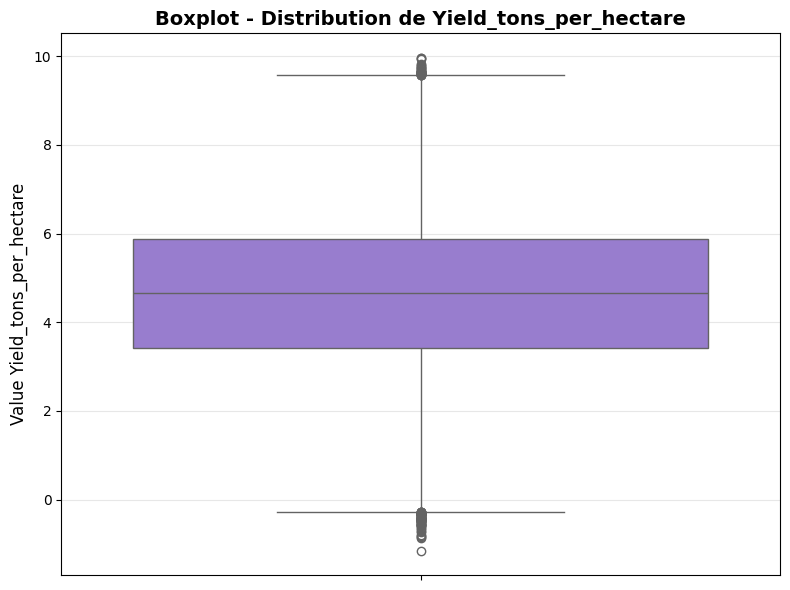


ANALYSE DES OUTLIERS
Q1 (25%) : 3.42
Q3 (75%) : 5.88
IQR : 2.46
Limite basse outliers : -0.27
Limite haute outliers : 9.57
Nombre d'outliers : 84 (0.01%)


In [11]:
# Créer le boxplot vertical
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_historiques['Yield_tons_per_hectare'], color='mediumpurple')
plt.ylabel('Value Yield_tons_per_hectare', fontsize=12)
plt.title('Boxplot - Distribution de Yield_tons_per_hectare', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Statistiques sur les outliers
Q1 = df_historiques['Yield_tons_per_hectare'].quantile(0.25)
Q3 = df_historiques['Yield_tons_per_hectare'].quantile(0.75)
IQR = Q3 - Q1
outlier_low = Q1 - 1.5 * IQR
outlier_high = Q3 + 1.5 * IQR

nb_outliers = ((df_historiques['Yield_tons_per_hectare'] < outlier_low) | 
               (df_historiques['Yield_tons_per_hectare'] > outlier_high)).sum()

print(f"\n{'='*50}")
print(f"ANALYSE DES OUTLIERS")
print(f"{'='*50}")
print(f"Q1 (25%) : {Q1:.2f}")
print(f"Q3 (75%) : {Q3:.2f}")
print(f"IQR : {IQR:.2f}")
print(f"Limite basse outliers : {outlier_low:.2f}")
print(f"Limite haute outliers : {outlier_high:.2f}")
print(f"Nombre d'outliers : {nb_outliers} ({nb_outliers/len(df_historiques)*100:.2f}%)")

Il y a visiblement des Outliers. A ce stade, on ne va supprimer que les valeurs négatives qui n'ont pas de sens et vérifier le rendement par type de culture pour les valeurs qui paraissent sur-dimensionnées.

## Suppression des valeurs négatives 

In [ ]:
df_historiques = df_historiques.drop(df_historiques[df_historiques['Yield_tons_per_hectare'] < 0].index)

In [ ]:
# Vérification après suppression
df_historiques.shape

## Analyse par culture

In [ ]:
sns.boxplot(data=df_historiques, x='Crop', y='Yield_tons_per_hectare')

La distribution est similaire entre cultures. On voit que les valeurs hautes sont bien des outliers, quelque soit le type de culture. On va donc les supprimer

## Suppression outliers hauts

In [ ]:
df_historiques = df_historiques.drop(df_historiques[df_historiques['Yield_tons_per_hectare'] > 9.50].index)

In [ ]:
# Vérification après suppression
df_historiques.shape

In [ ]:
# Vérification boxplot
sns.boxplot(data=df_historiques, x='Crop', y='Yield_tons_per_hectare')

# Analyse en Composantes Principales (ACP)

## Exécution PCA

In [ ]:
# Préparer données (encoder catégorielles)
df_pca = df_historiques.copy()
df_pca['Region_encoded'] = df_pca['Region'].astype('category').cat.codes
df_pca['Soil_encoded'] = df_pca['Soil_Type'].astype('category').cat.codes
df_pca['Weather_encoded'] = df_pca['Weather_Condition'].astype('category').cat.codes

# Variables pour PCA
features = ['Rainfall_mm', 'Temperature_Celsius', 'Region_encoded', 
            'Soil_encoded', 'Weather_encoded', 'Days_to_Harvest']
X = df_pca[features]

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA()
pca.fit(X_scaled)

# Variance expliquée
print("Variance expliquée par composante :")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var*100:.2f}%")

## Visualisation PCA - Variance expliquée

In [ ]:
# Scree plot
plt.figure(figsize=(10, 5))

# Graphique 1 : Variance par composante
plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), 
        pca.explained_variance_ratio_ * 100,
        alpha=0.7,
        color='steelblue')
plt.xlabel('Composante principale', fontsize=11)
plt.ylabel('Variance expliquée (%)', fontsize=11)
plt.title('Variance expliquée par composante', fontsize=12, fontweight='bold')
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.grid(axis='y', alpha=0.3)

# Graphique 2 : Variance cumulée
plt.subplot(1, 2, 2)
variance_cumulee = np.cumsum(pca.explained_variance_ratio_) * 100
plt.plot(range(1, len(variance_cumulee) + 1), 
         variance_cumulee, 
         marker='o', 
         linestyle='-',
         color='darkred',
         linewidth=2)
plt.xlabel('Nombre de composantes', fontsize=11)
plt.ylabel('Variance cumulée (%)', fontsize=11)
plt.title('Variance cumulée', fontsize=12, fontweight='bold')
plt.xticks(range(1, len(variance_cumulee) + 1))
plt.axhline(y=80, color='gray', linestyle='--', alpha=0.5, label='Seuil 80%')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("INTERPRÉTATION")
print("="*70)
print("Variance parfaitement équi-répartie (~16.7% par composante)")
print("→ Aucune composante dominante")
print("→ Variables totalement indépendantes les unes des autres")
print("→ Absence de structure multivariée dans les données")

## Interprétation et conclusion
**Résultats observés :**

L'ACP révèle une variance expliquée parfaitement uniforme sur les 6 composantes principales (~16.7% chacune). Ce résultat est caractéristique de variables totalement **indépendantes** les unes des autres, sans corrélation ni structure multivariée sous-jacente.

**Implications méthodologiques :**

Cette absence de structure confirme la nature **synthétique et artificielle** du dataset. Dans des données agricoles réelles, on observerait des corrélations naturelles (ex: température/pluviométrie, région/type de sol). Ici, les variables géographiques (Region, Soil_Type, Weather_Condition) n'apportent **aucune information structurelle** exploitable pour la modélisation.

#  Analyse des variables catégorielles

## Region

In [ ]:
df_historiques['Region'].value_counts()

Quatre régions qui sont en réalité les 4 points cardinaux. Distribution homogène. Colonne qui sera probablement à supprimer car un point cardinal est forcément relatif par rapport à la zone géographique du futur utilisateur. On va vérifier avant si cette information a un impact sur la cible.

In [ ]:
sns.boxplot(data=df_historiques, x='Region', y='Yield_tons_per_hectare')

**Conclusion** : aucun impact, boxplot complètement uniforme qui ne nous apprend rien. A supprimer

In [ ]:
# Suppression de la colonne Region
df_historiques = df_historiques.drop(columns='Region')

In [ ]:
# Vérification
df_historiques.shape

## Soil_type

In [ ]:
df_historiques['Soil_Type'].value_counts()

Distribution homogène. 

In [ ]:
sns.boxplot(data=df_historiques, x='Soil_Type', y='Yield_tons_per_hectare')

**Conclusion** : aucun impact, boxplot complètement uniforme qui ne nous apprend rien. A supprimer

In [ ]:
# Suppression de la colonne Region
df_historiques = df_historiques.drop(columns='Soil_Type')

In [ ]:
# Vérification
df_historiques.shape

## Crop

In [ ]:
df_historiques['Crop'].value_counts()

In [ ]:
sns.boxplot(data=df_historiques, x='Crop', y='Yield_tons_per_hectare')

**Conclusion** : distribution homogène mais cette variable reste essentielle pour la segmentation, on va donc la conserver

## Weather_Condition 

In [ ]:
sns.boxplot(data=df_historiques, x='Weather_Condition', y='Yield_tons_per_hectare')

**Conclusion** : aucun impact, boxplot complètement uniforme qui ne nous apprend rien. A supprimer

In [ ]:
# Suppression de la colonne Region
df_historiques = df_historiques.drop(columns='Weather_Condition')

In [ ]:
# Vérification
df_historiques.shape

# Analyse des valeurs booléennes 

## Fertilizer_Used 

In [ ]:
sns.boxplot(data=df_historiques, x='Fertilizer_Used', y='Yield_tons_per_hectare')

**IMPACT MAJEUR** visible (False: 4.0 t/ha, True: 6.5 t/ha = +60%) - **A conserver**

## Irrigation_Used

In [ ]:
sns.boxplot(data=df_historiques, x='Irrigation_Used', y='Yield_tons_per_hectare')

**IMPACT MAJEUR** visible (False: 4.0 t/ha, True: 5.5 t/ha = +60%) - **A conserver**

# Analyse des variables numériques

## Corrélations

In [ ]:
# Variables numériques vs cible SUR DATASET COMPLET
num_vars = ['Rainfall_mm', 'Temperature_Celsius', 'Days_to_Harvest']
correlations = df_historiques[num_vars + ['Yield_tons_per_hectare']].corr()

sns.heatmap(correlations, annot=True, cmap='coolwarm', center=0)
plt.title('Corrélations variables numériques')
plt.show()

**Résultats observés :**
- Temperature --> Yield : 0,09 (très faible)
- Days_to_Harvest --> Yield : 0,008 (quasi-nulle)
- Rainfall → Yield : 0,77 (FORTE)

**Interprétation**
- Rainfall est l'unique variable prédictive
- Temperature et Days_to_Harvest apportent juste des informations complémentaires et seront donc conservées.

# Dataset Final - Vue d'ensemble

In [ ]:
print("=== DATASET NETTOYÉ - RÉSUMÉ ===")
print(f"Shape finale : {df_historiques.shape}")
print(f"\nNombre de lignes par culture :")
print(df_historiques['Crop'].value_counts())

- Distribution homogène entre cultures (~166K lignes chacune)
- Rendements moyens similaires (~4.65 t/ha toutes cultures confondues)
- **Conclusion** : Ce dataset synthétique traite toutes les cultures de manière identique

# Sauvegarde 

In [ ]:
output_path = DONNEES_HISTORIQUES / "crop_yield_clean.csv"
df_historiques.to_csv(output_path, index=False)
print(f"✅ Dataset nettoyé sauvegardé : {output_path}")
print(f"Shape final : {df_historiques.shape}")